In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
pip install meteostat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 2.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 9.4 MB/s eta 0:00:00:00:01
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [8]:
import meteostat as ms

#POINT = ms.Point(50.1155, 8.6842, 113)  # Try with your location
POINT = ms.Point(52.4064, 16.9252)


# Get nearby weather stations
stations = ms.stations.nearby(POINT, limit=10, radius=500000)

print(stations)

                         name country region  latitude  longitude  elevation  \
id                                                                             
12330                  Poznan      PL     WP   52.4167    16.8333         86   
12418      Leszno-Strzyzewice      PL     WP   51.8333    16.5333         91   
12230                    Pila      PL     WP   53.1333    16.7500         72   
12400            Zielona Gora      PL     LU   51.9333    15.5333        192   
12435                  Kalisz      PL     WP   51.7333    18.0833        140   
12300             Gorzow Wlkp      PL     LU   52.7500    15.2833         72   
12225               Nadarzyce      PL     WP   53.4500    16.5000        129   
12345                    Kolo      PL     WP   52.2000    18.6667        115   
12226  Miroslawiec / Borujsko      PL     ZA   53.4000    16.1000         45   
12250                   Torun      PL     KP   53.0333    18.5833         69   

            timezone  distance  
id    

In [9]:
import meteostat as ms

STATION = '12330' 

# Get station inventory
inventory = ms.stations.inventory(STATION)

print(f"Data available from {inventory.start} to {inventory.end}.")

inventory = ms.stations.inventory(STATION)

Data available from 1931-01-02 to 2026-03-17.


In [13]:
# Import Meteostat library
import meteostat as ms

POINT = ms.Point(52.4064, 16.9252)

STATION = '12330' 

# Get climate normals data
ts = ms.normals(STATION, 1961, 1990)
df = ts.fetch()

# Print DataFrame
print(df)

#wyjaśnienie parametrów
#https://dev.meteostat.net/parameters

      temp  txmx  prcp    pres
time                          
1     -2.0  <NA>  29.6  1016.9
2     -0.9  <NA>  23.7  1016.7
3      2.8  13.9  26.7  1015.6
4      7.7  24.0  35.8  1014.0
5     13.2  27.0  52.9  1015.3
6     16.6  32.8  60.4  1015.0
7     17.9  36.1  69.2  1015.2
8     17.4  30.0  56.9  1015.5
9     13.5  30.0  43.0  1016.9
10     8.9  <NA>  38.7  1018.2
11     3.7  <NA>  39.0  1015.4
12    -0.2  <NA>  37.4  1015.6


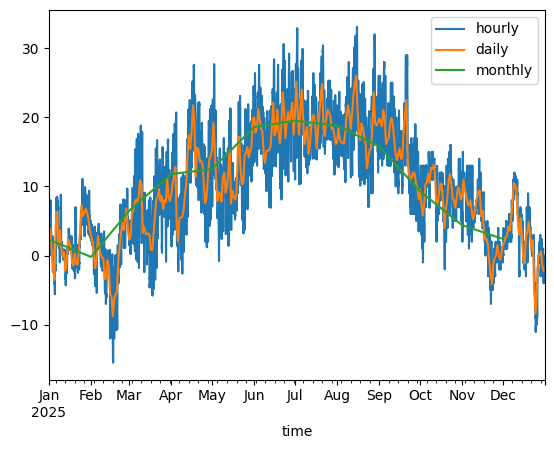

In [26]:
from datetime import datetime
import meteostat as ms
import matplotlib.pyplot as plt

# Set time period
start = datetime(2025, 1, 1)
end = datetime(2025, 12, 31, 23, 59)

STATION = '12330' 

# Get hourly data
ts_hourly = ms.hourly(STATION, start, end)
df_hourly = ts_hourly.fetch()

ts_daily = ms.daily(STATION, start, end)
df_daily = ts_daily.fetch()

ts_monthly = ms.monthly(STATION, start, end)
df_monthly = ts_monthly.fetch()

# Print DataFrame
#print(df_hourly)

ax = df_hourly.plot(y=[ms.Parameter.TEMP], label=['hourly'])
df_daily.plot(y=[ms.Parameter.TEMP], ax=ax, label=['daily'])
df_monthly.plot(y=[ms.Parameter.TEMP], ax=ax, label=['monthly'])
#ax = df.plot(y=[ms.Parameter.TEMP])
# ax.set_xlim("2018-01-01", "2020-12-31")
#ax.set_xlim("2025-12-01", "2025-12-31")

plt.show()
